# EDA 09 - Revenue Rolling Statistics

This notebook analyzes leakage-safe rolling statistics of daily revenue using `sales.csv`, with a focus on short-term trend, volatility, rolling min/max behavior, and forecast feature candidates.

## 1. Setup and file discovery

Locate `sales.csv` recursively from the current working directory and configure common analysis settings. All outputs are displayed directly in the notebook.

In [1]:
import os
import re
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 240)
pd.set_option("display.max_rows", 300)
pd.set_option("display.max_colwidth", 160)

PROJECT_ROOT = Path(os.getcwd())
SALES_FILENAME = "sales.csv"
ROLL_WINDOWS = [7, 14, 30, 90]
VOL_WINDOWS = [7, 30]
ROLL_FEATURE_COLUMNS = [
    "revenue_roll_mean_7",
    "revenue_roll_mean_14",
    "revenue_roll_mean_30",
    "revenue_roll_mean_90",
    "revenue_roll_std_7",
    "revenue_roll_std_30",
    "revenue_roll_max_30",
    "revenue_roll_min_30",
    "roll_mean_7_vs_30",
    "roll_mean_30_vs_90",
]

analysis_ready = False
warning_messages = []
daily = pd.DataFrame()
daily_continuous = pd.DataFrame()
rolling_df = pd.DataFrame()
rolling_feature_audit_df = pd.DataFrame()
rolling_window_metrics_df = pd.DataFrame()
volatility_periods_df = pd.DataFrame()
cv_periods_df = pd.DataFrame()
breakout_days_df = pd.DataFrame()
trend_periods_df = pd.DataFrame()
feature_preview = pd.DataFrame()

missing_date_statement = "Not evaluated."
most_informative_window = None
rolling_mean_statement = "Not evaluated."
short_term_trend_statement = "Not evaluated."
cv_statement = "Not evaluated."
breakout_statement = "Not evaluated."
recommended_rolling_features = []
high_volatility_period_text = "None identified"
low_volatility_period_text = "None identified"


def money_formatter(value, _position=None):
    if pd.isna(value):
        return ""
    abs_value = abs(value)
    if abs_value >= 1_000_000_000:
        return f"{value / 1_000_000_000:,.1f}B"
    if abs_value >= 1_000_000:
        return f"{value / 1_000_000:,.1f}M"
    if abs_value >= 1_000:
        return f"{value / 1_000:,.0f}K"
    return f"{value:,.0f}"


currency_axis = FuncFormatter(money_formatter)

sales_matches = sorted(PROJECT_ROOT.rglob(SALES_FILENAME), key=lambda p: (len(p.parts), str(p).lower()))
sales_path = sales_matches[0] if sales_matches else None

file_discovery_df = pd.DataFrame([{
    "file": SALES_FILENAME,
    "found": sales_path is not None,
    "path": str(sales_path.relative_to(PROJECT_ROOT)) if sales_path else None,
    "match_count": len(sales_matches),
}])

if sales_path is None:
    warning_messages.append("sales.csv was not found under the current working directory.")

print(f"Project root: {PROJECT_ROOT}")
display(file_discovery_df)
if len(sales_matches) > 1:
    display(pd.DataFrame({"matched_paths": [str(p.relative_to(PROJECT_ROOT)) for p in sales_matches]}))

Project root: D:\Code\Datathon 2026


,file,found,path,match_count
0,sales.csv,True,datathon-2026-round-1\sales.csv,1


## 2. Load sales data

Load the sales file safely with pandas. If loading fails, later sections display warnings and skip dependent analysis rather than crashing.

In [2]:
sales_raw = None
load_error = None

if sales_path is None:
    load_error = "sales.csv was not found."
else:
    try:
        sales_raw = pd.read_csv(sales_path, low_memory=False)
    except Exception as exc:
        load_error = repr(exc)
        warning_messages.append(f"Could not load sales.csv: {load_error}")

if sales_raw is None:
    load_summary_df = pd.DataFrame([{
        "file": SALES_FILENAME,
        "loaded": False,
        "rows": np.nan,
        "columns": np.nan,
        "error": load_error,
    }])
else:
    load_summary_df = pd.DataFrame([{
        "file": SALES_FILENAME,
        "loaded": True,
        "rows": len(sales_raw),
        "columns": len(sales_raw.columns),
        "error": "",
    }])

display(load_summary_df)
if sales_raw is not None:
    display(sales_raw.head())

,file,loaded,rows,columns,error
0,sales.csv,True,3833,3,


,Date,Revenue,COGS
0,2012-07-04,5123547.94,3982991.19
1,2012-07-05,2751773.45,2150580.23
2,2012-07-06,3054029.42,2517632.84
3,2012-07-07,2667930.94,2108246.62
4,2012-07-08,2360851.90,1808622.79


## 3. Identify date and revenue columns

Detect the most likely date and revenue columns using normalized column names, date parse success, numeric parse success, and revenue-related naming hints. If a direct revenue column is unavailable, numeric columns are scored as possible revenue proxies.

In [3]:
def normalize_name(name):
    return re.sub(r"[^a-z0-9]+", "_", str(name).strip().lower()).strip("_")


def non_empty_mask(series):
    if pd.api.types.is_object_dtype(series) or pd.api.types.is_string_dtype(series):
        return series.astype("string").str.strip().ne("") & series.notna()
    return series.notna()


def numeric_series(series):
    if pd.api.types.is_numeric_dtype(series):
        return pd.to_numeric(series, errors="coerce")
    cleaned = (
        series.astype("string")
        .str.strip()
        .str.replace(",", "", regex=False)
        .str.replace("$", "", regex=False)
        .str.replace(r"^\((.*)\)$", r"-\1", regex=True)
    )
    return pd.to_numeric(cleaned, errors="coerce")


def parse_datetime_series(series):
    if pd.api.types.is_datetime64_any_dtype(series):
        return pd.to_datetime(series, errors="coerce")
    return pd.to_datetime(series, errors="coerce")


def date_score(column_name, series):
    name = normalize_name(column_name)
    name_tokens = set(name.split("_"))
    exact_date_names = {"date", "ds", "day", "sales_date", "order_date", "transaction_date", "created_at", "timestamp"}
    date_terms = {"date", "day", "time", "timestamp", "datetime"}

    name_points = 0
    if name in exact_date_names:
        name_points += 5
    elif name_tokens & date_terms or any(term in name for term in ["date", "timestamp", "datetime"]):
        name_points += 3

    if pd.api.types.is_numeric_dtype(series) and name_points == 0:
        return {
            "column": column_name,
            "normalized_name": name,
            "date_score": -5.0,
            "date_parse_success": 0.0,
            "plausible_date_share": 0.0,
            "non_empty_values": int(non_empty_mask(series).sum()),
        }

    parsed = parse_datetime_series(series)
    mask = non_empty_mask(series)
    non_empty = int(mask.sum())
    parsed_valid = parsed[mask].notna() if non_empty else pd.Series(dtype=bool)
    parse_success = float(parsed_valid.mean()) if non_empty else 0.0

    parsed_non_null = parsed[mask].dropna()
    if len(parsed_non_null):
        plausible = parsed_non_null.between(pd.Timestamp("1990-01-01"), pd.Timestamp("2100-12-31"))
        plausible_share = float(plausible.mean())
        unique_dates = int(parsed_non_null.dt.normalize().nunique())
    else:
        plausible_share = 0.0
        unique_dates = 0

    score = name_points + (3 * parse_success) + (2 * plausible_share) + min(unique_dates / 20, 1)
    return {
        "column": column_name,
        "normalized_name": name,
        "date_score": round(score, 4),
        "date_parse_success": round(parse_success, 4),
        "plausible_date_share": round(plausible_share, 4),
        "non_empty_values": non_empty,
    }


def revenue_score(column_name, series):
    name = normalize_name(column_name)
    name_tokens = set(name.split("_"))
    positive_terms = {
        "revenue": 7,
        "sales": 5,
        "sale": 4,
        "amount": 4,
        "total": 3,
        "value": 2,
        "gmv": 5,
        "turnover": 5,
        "net": 2,
        "gross": 2,
    }
    negative_terms = {
        "id": 6,
        "key": 5,
        "code": 4,
        "date": 6,
        "time": 5,
        "year": 4,
        "month": 4,
        "day": 4,
        "qty": 5,
        "quantity": 5,
        "count": 4,
        "cost": 4,
        "cogs": 5,
        "price": 2,
        "rate": 3,
        "percent": 4,
        "percentage": 4,
    }

    name_points = 0
    for term, points in positive_terms.items():
        if term in name_tokens or term in name:
            name_points += points

    penalty = 0
    for term, points in negative_terms.items():
        if term in name_tokens or term in name:
            penalty += points

    numeric = numeric_series(series)
    mask = non_empty_mask(series)
    non_empty = int(mask.sum())
    numeric_non_null = int(numeric[mask].notna().sum()) if non_empty else 0
    numeric_success = numeric_non_null / non_empty if non_empty else 0.0
    numeric_valid = numeric[mask].dropna()

    if len(numeric_valid):
        positive_share = float((numeric_valid > 0).mean())
        nonzero_share = float((numeric_valid != 0).mean())
        mean_value = float(numeric_valid.mean())
        std_value = float(numeric_valid.std(ddof=1)) if len(numeric_valid) > 1 else 0.0
        abs_median = float(numeric_valid.abs().median())
    else:
        positive_share = 0.0
        nonzero_share = 0.0
        mean_value = np.nan
        std_value = np.nan
        abs_median = 0.0

    variability_points = 1.0 if pd.notna(std_value) and std_value > 0 else 0.0
    magnitude_points = min(np.log10(abs_median + 1) / 4, 1.5) if abs_median > 0 else 0.0
    score = name_points - penalty + (3 * numeric_success) + positive_share + nonzero_share + variability_points + magnitude_points

    return {
        "column": column_name,
        "normalized_name": name,
        "revenue_score": round(float(score), 4),
        "numeric_parse_success": round(float(numeric_success), 4),
        "positive_share": round(float(positive_share), 4),
        "non_empty_values": non_empty,
        "numeric_values": numeric_non_null,
        "mean_numeric_value": mean_value,
        "std_numeric_value": std_value,
        "has_revenue_name_hint": any(term in name for term in ["revenue", "sales", "amount", "gmv", "turnover"]),
    }


if sales_raw is None or sales_raw.empty:
    date_col = None
    revenue_col = None
    parsed_date = None
    parsed_revenue = None
    date_candidates_df = pd.DataFrame()
    revenue_candidates_df = pd.DataFrame()
    column_detection_df = pd.DataFrame([{"warning": "sales.csv was not loaded or is empty."}])
    warning_messages.append("Column detection skipped because sales.csv was not loaded or is empty.")
else:
    date_candidates_df = pd.DataFrame([date_score(col, sales_raw[col]) for col in sales_raw.columns])
    revenue_candidates_df = pd.DataFrame([revenue_score(col, sales_raw[col]) for col in sales_raw.columns])

    date_candidates_df = date_candidates_df.sort_values(["date_score", "date_parse_success", "plausible_date_share"], ascending=False)
    revenue_candidates_df = revenue_candidates_df.sort_values(["revenue_score", "numeric_parse_success", "positive_share"], ascending=False)

    selected_date = date_candidates_df.iloc[0] if len(date_candidates_df) else None
    selected_revenue = revenue_candidates_df.iloc[0] if len(revenue_candidates_df) else None

    date_col = None
    revenue_col = None
    if selected_date is not None and selected_date["date_parse_success"] >= 0.50 and selected_date["plausible_date_share"] >= 0.50:
        date_col = selected_date["column"]

    if selected_revenue is not None and selected_revenue["numeric_parse_success"] >= 0.75 and selected_revenue["revenue_score"] >= 2.0:
        revenue_col = selected_revenue["column"]

    parsed_date = parse_datetime_series(sales_raw[date_col]) if date_col else None
    parsed_revenue = numeric_series(sales_raw[revenue_col]) if revenue_col else None

    if date_col is None:
        warning_messages.append("No usable date column was found. Rolling-statistics EDA cannot be completed.")
    if revenue_col is None:
        warning_messages.append("No usable revenue or revenue-like numeric column was found. Rolling-statistics EDA cannot be completed.")
    elif not bool(selected_revenue["has_revenue_name_hint"]):
        warning_messages.append(f"Revenue column was inferred from numeric data rather than a direct revenue name: {revenue_col}.")

    column_detection_df = pd.DataFrame([{
        "selected_date_column": date_col,
        "selected_revenue_column": revenue_col,
        "date_parse_success": float(parsed_date.notna().mean()) if parsed_date is not None else np.nan,
        "revenue_numeric_success": float(parsed_revenue.notna().mean()) if parsed_revenue is not None else np.nan,
        "revenue_inferred_without_name_hint": bool(revenue_col and not bool(selected_revenue["has_revenue_name_hint"])),
    }])

print("Selected columns")
display(column_detection_df)
if len(date_candidates_df):
    print("Date candidates")
    display(date_candidates_df)
if len(revenue_candidates_df):
    print("Revenue candidates")
    display(revenue_candidates_df)

Selected columns


,selected_date_column,selected_revenue_column,date_parse_success,revenue_numeric_success,revenue_inferred_without_name_hint
0,Date,Revenue,1.0,1.0,False


Date candidates


,column,normalized_name,date_score,date_parse_success,plausible_date_share,non_empty_values
0,Date,date,11.0,1.0,1.0,3833
1,Revenue,revenue,-5.0,0.0,0.0,3833
2,COGS,cogs,-5.0,0.0,0.0,3833


Revenue candidates


,column,normalized_name,revenue_score,numeric_parse_success,positive_share,non_empty_values,numeric_values,mean_numeric_value,std_numeric_value,has_revenue_name_hint
1,Revenue,revenue,14.5,1.0,1.0,3833,3833,4.286584e+06,2.624840e+06,True
2,COGS,cogs,2.5,1.0,1.0,3833,3833,3.695134e+06,2.219789e+06,False
0,Date,date,-6.0,0.0,0.0,3833,0,NaN,NaN,False


## 4. Prepare daily revenue time series

Parse dates and revenue, aggregate multiple rows per date by summing revenue, sort by date, and create a continuous daily calendar index. Missing calendar dates are left as missing values rather than filled with artificial revenue.

In [4]:
if sales_raw is None or date_col is None or revenue_col is None:
    analysis_ready = False
    prep_summary_df = pd.DataFrame([{"ready": False, "warning": "Missing loaded data, date column, or revenue column."}])
    display(prep_summary_df)
else:
    work = pd.DataFrame({
        "date_raw": sales_raw[date_col],
        "revenue_raw": sales_raw[revenue_col],
        "date": parsed_date,
        "revenue": parsed_revenue,
    })
    work["date"] = pd.to_datetime(work["date"], errors="coerce").dt.normalize()

    initial_rows = len(work)
    invalid_date_rows = int(work["date"].isna().sum())
    invalid_revenue_rows = int(work["revenue"].isna().sum())
    work = work.dropna(subset=["date", "revenue"]).copy()

    if work.empty:
        analysis_ready = False
        warning_messages.append("No rows remained after dropping invalid dates or revenue values.")
        prep_summary_df = pd.DataFrame([{
            "ready": False,
            "initial_rows": initial_rows,
            "invalid_date_rows": invalid_date_rows,
            "invalid_revenue_rows": invalid_revenue_rows,
            "usable_rows": 0,
        }])
        display(prep_summary_df)
    else:
        duplicate_date_rows = int(work.duplicated("date", keep=False).sum())
        daily = (
            work.groupby("date", as_index=False)
            .agg(revenue=("revenue", "sum"), source_rows=("revenue", "size"))
            .sort_values("date")
            .reset_index(drop=True)
        )

        full_calendar = pd.date_range(daily["date"].min(), daily["date"].max(), freq="D")
        daily_continuous = (
            daily.set_index("date")
            .reindex(full_calendar)
            .rename_axis("date")
            .reset_index()
        )
        daily_continuous["was_observed"] = daily_continuous["revenue"].notna()
        daily_continuous["source_rows"] = daily_continuous["source_rows"].fillna(0).astype(int)
        daily_continuous["day_index"] = np.arange(len(daily_continuous))

        observed_dates = pd.DatetimeIndex(daily["date"])
        missing_dates = full_calendar.difference(observed_dates)
        inferred_frequency = pd.infer_freq(observed_dates) if len(observed_dates) >= 3 else None
        median_gap_days = float(daily["date"].diff().dt.days.dropna().median()) if len(daily) > 1 else np.nan

        analysis_ready = True
        if duplicate_date_rows:
            warning_messages.append(f"Found {duplicate_date_rows:,} source rows on dates with duplicates; revenue was aggregated by date using sum.")
        if len(missing_dates):
            warning_messages.append(f"Found {len(missing_dates):,} missing calendar dates between the first and last observed sales dates.")
        if pd.notna(median_gap_days) and median_gap_days > 1:
            warning_messages.append(f"Observed dates are not contiguous daily records; median gap is {median_gap_days:.1f} days.")

        missing_date_statement = (
            "No missing calendar dates were found; rolling statistics use the observed daily revenue series on a continuous calendar."
            if len(missing_dates) == 0
            else f"{len(missing_dates):,} missing calendar dates were left as NaN; rolling statistics skip missing revenue values but require minimum observed history."
        )

        prep_summary_df = pd.DataFrame([{
            "ready": True,
            "initial_rows": initial_rows,
            "invalid_date_rows": invalid_date_rows,
            "invalid_revenue_rows": invalid_revenue_rows,
            "usable_source_rows": len(work),
            "daily_observed_rows_after_aggregation": len(daily),
            "continuous_calendar_rows": len(daily_continuous),
            "duplicate_date_source_rows": duplicate_date_rows,
            "first_date": daily["date"].min().date(),
            "last_date": daily["date"].max().date(),
            "missing_calendar_days": len(missing_dates),
            "inferred_observed_frequency": inferred_frequency,
            "median_gap_days": median_gap_days,
        }])
        display(prep_summary_df)
        print(missing_date_statement)
        display(daily_continuous.head(10))

,ready,initial_rows,invalid_date_rows,invalid_revenue_rows,usable_source_rows,daily_observed_rows_after_aggregation,continuous_calendar_rows,duplicate_date_source_rows,first_date,last_date,missing_calendar_days,inferred_observed_frequency,median_gap_days
0,True,3833,0,0,3833,3833,3833,0,2012-07-04,2022-12-31,0,D,1.0


No missing calendar dates were found; rolling statistics use the observed daily revenue series on a continuous calendar.


,date,revenue,source_rows,was_observed,day_index
0,2012-07-04,5123547.94,1,True,0
1,2012-07-05,2751773.45,1,True,1
2,2012-07-06,3054029.42,1,True,2
3,2012-07-07,2667930.94,1,True,3
4,2012-07-08,2360851.90,1,True,4
5,2012-07-09,3548386.46,1,True,5
6,2012-07-10,5234938.62,1,True,6
7,2012-07-11,5582884.78,1,True,7
8,2012-07-12,5734632.02,1,True,8
9,2012-07-13,5309511.71,1,True,9


## 5. Leakage-safe rolling feature construction

Every rolling feature is computed from `revenue.shift(1)` before applying the rolling window. This means the feature value for date `t` only uses revenue values from dates before `t`.

In [5]:
def min_periods_for_window(window):
    if window <= 7:
        return 3
    return max(5, int(np.ceil(window * 0.5)))


def extract_flag_periods(df, flag_col, value_col, period_type, top_n=None):
    flagged = df.loc[df[flag_col].fillna(False), ["date", value_col]].copy()
    if flagged.empty:
        return pd.DataFrame(columns=["period_type", "start_date", "end_date", "days", "max_value", "min_value", "mean_value"])
    flagged["break"] = flagged["date"].diff().dt.days.ne(1).cumsum()
    rows = []
    for _, group in flagged.groupby("break"):
        rows.append({
            "period_type": period_type,
            "start_date": group["date"].min().date(),
            "end_date": group["date"].max().date(),
            "days": len(group),
            "max_value": group[value_col].max(),
            "min_value": group[value_col].min(),
            "mean_value": group[value_col].mean(),
        })
    result = pd.DataFrame(rows).sort_values(["days", "max_value"], ascending=[False, False]).reset_index(drop=True)
    if top_n is not None:
        result = result.head(top_n)
    return result


if not analysis_ready:
    print("WARNING: Skipping rolling feature construction because usable daily revenue data is not available.")
else:
    rolling_df = daily_continuous[["date", "revenue", "was_observed", "source_rows", "day_index"]].copy()
    shifted_revenue = rolling_df["revenue"].shift(1)
    rolling_df["revenue_shift_1_for_rolling"] = shifted_revenue

    feature_audit_rows = []
    for window in ROLL_WINDOWS:
        min_periods = min_periods_for_window(window)
        rolling_df[f"revenue_roll_mean_{window}"] = shifted_revenue.rolling(window=window, min_periods=min_periods).mean()
        feature_audit_rows.append({
            "feature": f"revenue_roll_mean_{window}",
            "source_series": "revenue.shift(1)",
            "window_days": window,
            "min_periods": min_periods,
            "leakage_safe": True,
        })

    for window in VOL_WINDOWS:
        min_periods = min_periods_for_window(window)
        rolling_df[f"revenue_roll_std_{window}"] = shifted_revenue.rolling(window=window, min_periods=min_periods).std()
        feature_audit_rows.append({
            "feature": f"revenue_roll_std_{window}",
            "source_series": "revenue.shift(1)",
            "window_days": window,
            "min_periods": min_periods,
            "leakage_safe": True,
        })

    rolling_df["revenue_roll_max_30"] = shifted_revenue.rolling(window=30, min_periods=min_periods_for_window(30)).max()
    rolling_df["revenue_roll_min_30"] = shifted_revenue.rolling(window=30, min_periods=min_periods_for_window(30)).min()
    feature_audit_rows.extend([
        {"feature": "revenue_roll_max_30", "source_series": "revenue.shift(1)", "window_days": 30, "min_periods": min_periods_for_window(30), "leakage_safe": True},
        {"feature": "revenue_roll_min_30", "source_series": "revenue.shift(1)", "window_days": 30, "min_periods": min_periods_for_window(30), "leakage_safe": True},
    ])

    rolling_df["roll_mean_7_vs_30"] = rolling_df["revenue_roll_mean_7"] - rolling_df["revenue_roll_mean_30"]
    rolling_df["roll_mean_30_vs_90"] = rolling_df["revenue_roll_mean_30"] - rolling_df["revenue_roll_mean_90"]
    feature_audit_rows.extend([
        {"feature": "roll_mean_7_vs_30", "source_series": "shifted rolling means", "window_days": "7 minus 30", "min_periods": "feature-specific", "leakage_safe": True},
        {"feature": "roll_mean_30_vs_90", "source_series": "shifted rolling means", "window_days": "30 minus 90", "min_periods": "feature-specific", "leakage_safe": True},
    ])

    near_zero = rolling_df["revenue_roll_mean_30"].abs() < 1e-9
    rolling_df["revenue_roll_cv_30"] = np.where(
        near_zero,
        np.nan,
        rolling_df["revenue_roll_std_30"] / rolling_df["revenue_roll_mean_30"].abs(),
    )
    feature_audit_rows.append({
        "feature": "revenue_roll_cv_30",
        "source_series": "revenue_roll_std_30 / abs(revenue_roll_mean_30)",
        "window_days": 30,
        "min_periods": min_periods_for_window(30),
        "leakage_safe": True,
    })

    rolling_feature_audit_df = pd.DataFrame(feature_audit_rows)
    display(rolling_feature_audit_df)
    print("Confirmed: all rolling forecast features are based on shifted revenue, so same-day revenue is not used to construct same-day rolling features.")
    display(rolling_df.head(15))

,feature,source_series,window_days,min_periods,leakage_safe
0,revenue_roll_mean_7,revenue.shift(1),7,3,True
1,revenue_roll_mean_14,revenue.shift(1),14,7,True
2,revenue_roll_mean_30,revenue.shift(1),30,15,True
3,revenue_roll_mean_90,revenue.shift(1),90,45,True
4,revenue_roll_std_7,revenue.shift(1),7,3,True
5,revenue_roll_std_30,revenue.shift(1),30,15,True
6,revenue_roll_max_30,revenue.shift(1),30,15,True
7,revenue_roll_min_30,revenue.shift(1),30,15,True
8,roll_mean_7_vs_30,shifted rolling means,7 minus 30,feature-specific,True
9,roll_mean_30_vs_90,shifted rolling means,30 minus 90,feature-specific,True


Confirmed: all rolling forecast features are based on shifted revenue, so same-day revenue is not used to construct same-day rolling features.


,date,revenue,was_observed,source_rows,day_index,revenue_shift_1_for_rolling,revenue_roll_mean_7,revenue_roll_mean_14,revenue_roll_mean_30,revenue_roll_mean_90,revenue_roll_std_7,revenue_roll_std_30,revenue_roll_max_30,revenue_roll_min_30,roll_mean_7_vs_30,roll_mean_30_vs_90,revenue_roll_cv_30
0,2012-07-04,5123547.94,True,1,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2012-07-05,2751773.45,True,1,1,5123547.94,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2012-07-06,3054029.42,True,1,2,2751773.45,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2012-07-07,2667930.94,True,1,3,3054029.42,3.643117e+06,NaN,NaN,NaN,1.290967e+06,NaN,NaN,NaN,NaN,NaN,NaN
4,2012-07-08,2360851.90,True,1,4,2667930.94,3.399320e+06,NaN,NaN,NaN,1.161383e+06,NaN,NaN,NaN,NaN,NaN,NaN
5,2012-07-09,3548386.46,True,1,5,2360851.90,3.191627e+06,NaN,NaN,NaN,1.107832e+06,NaN,NaN,NaN,NaN,NaN,NaN
6,2012-07-10,5234938.62,True,1,6,3548386.46,3.251087e+06,NaN,NaN,NaN,1.001522e+06,NaN,NaN,NaN,NaN,NaN,NaN
7,2012-07-11,5582884.78,True,1,7,5234938.62,3.534494e+06,3.534494e+06,NaN,NaN,1.182417e+06,NaN,NaN,NaN,NaN,NaN,NaN
8,2012-07-12,5734632.02,True,1,8,5582884.78,3.600114e+06,3.790543e+06,NaN,NaN,1.292887e+06,NaN,NaN,NaN,NaN,NaN,NaN
9,2012-07-13,5309511.71,True,1,9,5734632.02,4.026236e+06,4.006553e+06,NaN,NaN,1.448836e+06,NaN,NaN,NaN,NaN,NaN,NaN


## 6. Rolling mean analysis

Compare 7-, 14-, 30-, and 90-day shifted rolling means. The 7-day window is more responsive, the 30-day window is a medium-term trend, and the 90-day window is smoother but slower to react.

,window_days,valid_days,mae_vs_current_revenue,rmse_vs_current_revenue,correlation_with_current_revenue,mean_abs_daily_change_in_roll_mean,relative_smoothness_vs_revenue
0,7,3830,1.248833e+06,1.931437e+06,0.695108,248711.308278,0.278555
1,14,3826,1.369837e+06,1.971207e+06,0.669805,135036.828486,0.151241
2,30,3818,1.338476e+06,1.924729e+06,0.682366,49945.976454,0.055939
3,90,3788,1.592849e+06,2.222145e+06,0.547316,24727.112867,0.027694


The 7-day rolling mean appears most informative by a simple combined ranking of lower error, higher correlation, and smoother movement.


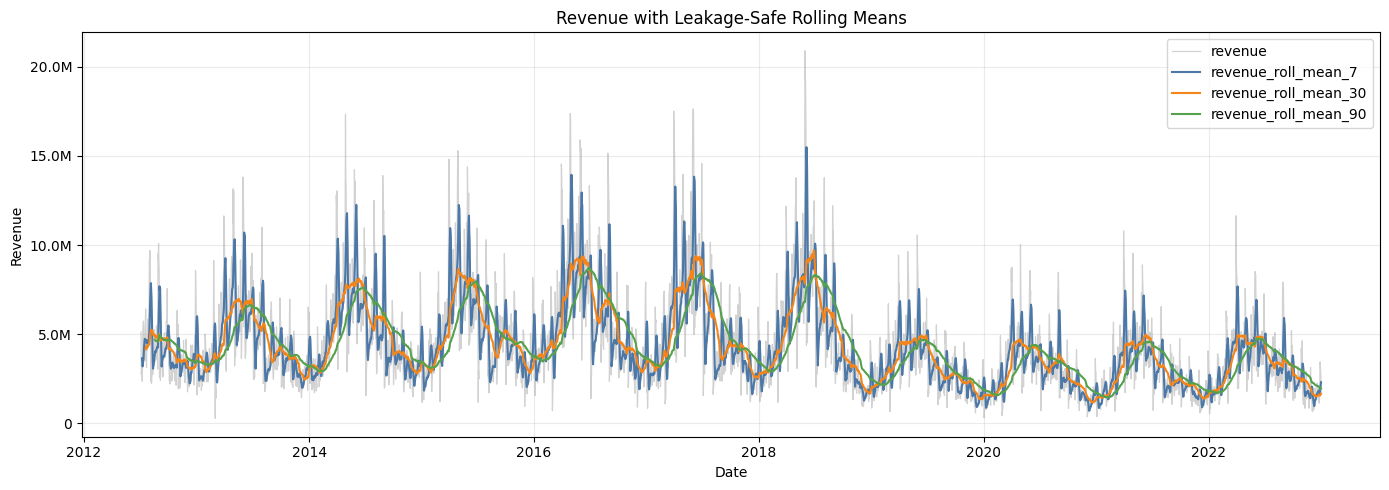

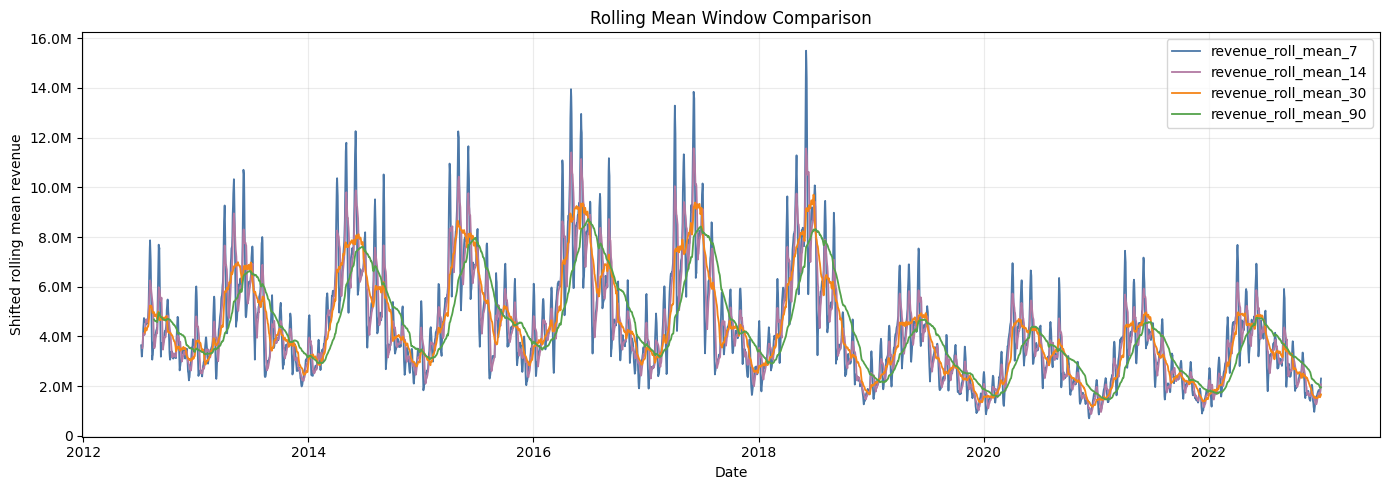

In [6]:
if not analysis_ready or rolling_df.empty:
    print("WARNING: Skipping rolling mean analysis because rolling features are not available.")
else:
    metric_rows = []
    for window in ROLL_WINDOWS:
        feature = f"revenue_roll_mean_{window}"
        valid = rolling_df.dropna(subset=["revenue", feature]).copy()
        if valid.empty:
            metric_rows.append({
                "window_days": window,
                "valid_days": 0,
                "mae_vs_current_revenue": np.nan,
                "rmse_vs_current_revenue": np.nan,
                "correlation_with_current_revenue": np.nan,
                "mean_abs_daily_change_in_roll_mean": np.nan,
                "relative_smoothness_vs_revenue": np.nan,
            })
            continue
        errors = valid["revenue"] - valid[feature]
        roll_change = rolling_df[feature].diff().abs().mean(skipna=True)
        revenue_change = rolling_df["revenue"].diff().abs().mean(skipna=True)
        metric_rows.append({
            "window_days": window,
            "valid_days": len(valid),
            "mae_vs_current_revenue": errors.abs().mean(),
            "rmse_vs_current_revenue": float(np.sqrt(np.mean(np.square(errors)))),
            "correlation_with_current_revenue": valid["revenue"].corr(valid[feature]),
            "mean_abs_daily_change_in_roll_mean": roll_change,
            "relative_smoothness_vs_revenue": roll_change / revenue_change if revenue_change and pd.notna(revenue_change) else np.nan,
        })

    rolling_window_metrics_df = pd.DataFrame(metric_rows)
    valid_metrics = rolling_window_metrics_df.dropna(subset=["mae_vs_current_revenue", "correlation_with_current_revenue"]).copy()
    if not valid_metrics.empty:
        valid_metrics["mae_rank"] = valid_metrics["mae_vs_current_revenue"].rank(method="min")
        valid_metrics["corr_rank"] = valid_metrics["correlation_with_current_revenue"].rank(ascending=False, method="min")
        valid_metrics["smoothness_rank"] = valid_metrics["relative_smoothness_vs_revenue"].rank(method="min")
        valid_metrics["combined_rank"] = valid_metrics["mae_rank"] + valid_metrics["corr_rank"] + 0.5 * valid_metrics["smoothness_rank"]
        most_informative_window = int(valid_metrics.sort_values("combined_rank").iloc[0]["window_days"])
        rolling_mean_statement = (
            f"The {most_informative_window}-day rolling mean appears most informative by a simple combined ranking of lower error, higher correlation, and smoother movement."
        )
    else:
        most_informative_window = None
        rolling_mean_statement = "No rolling mean window had enough valid data for comparison."

    display(rolling_window_metrics_df)
    print(rolling_mean_statement)

    plot_df = rolling_df.dropna(subset=["revenue"]).copy()
    fig, ax = plt.subplots(figsize=(14, 5))
    ax.plot(plot_df["date"], plot_df["revenue"], label="revenue", color="#9D9D9D", alpha=0.45, linewidth=0.9)
    for feature, color in [("revenue_roll_mean_7", "#4C78A8"), ("revenue_roll_mean_30", "#F58518"), ("revenue_roll_mean_90", "#54A24B")]:
        ax.plot(rolling_df["date"], rolling_df[feature], label=feature, linewidth=1.5, color=color)
    ax.set_title("Revenue with Leakage-Safe Rolling Means")
    ax.set_xlabel("Date")
    ax.set_ylabel("Revenue")
    ax.yaxis.set_major_formatter(currency_axis)
    ax.grid(alpha=0.25)
    ax.legend()
    plt.tight_layout()
    plt.show()

    fig, ax = plt.subplots(figsize=(14, 5))
    for feature, color in [
        ("revenue_roll_mean_7", "#4C78A8"),
        ("revenue_roll_mean_14", "#B279A2"),
        ("revenue_roll_mean_30", "#F58518"),
        ("revenue_roll_mean_90", "#54A24B"),
    ]:
        ax.plot(rolling_df["date"], rolling_df[feature], label=feature, linewidth=1.3, color=color)
    ax.set_title("Rolling Mean Window Comparison")
    ax.set_xlabel("Date")
    ax.set_ylabel("Shifted rolling mean revenue")
    ax.yaxis.set_major_formatter(currency_axis)
    ax.grid(alpha=0.25)
    ax.legend()
    plt.tight_layout()
    plt.show()

## 7. Rolling volatility analysis

Use leakage-safe 7- and 30-day rolling standard deviations to identify unusually high and low volatility periods. Thresholds are based on the empirical 90th and 10th percentiles of valid 30-day rolling standard deviation values.

,rolling_std_30_high_volatility_threshold_p90,rolling_std_30_low_volatility_threshold_p10,valid_rolling_std_30_days
0,2.837991e+06,775036.406593,3818


Top high-volatility days by shifted 30-day rolling standard deviation


,date,revenue,revenue_roll_mean_30,revenue_roll_std_30,revenue_roll_std_7
2167,2018-06-10,6333777.67,9.032729e+06,4.584332e+06,3.230372e+06
2166,2018-06-09,7018402.90,9.040424e+06,4.581027e+06,5.207253e+06
2168,2018-06-11,7812992.68,9.046054e+06,4.575587e+06,9.684987e+05
2160,2018-06-03,13779702.07,8.783790e+06,4.563286e+06,6.175925e+06
2165,2018-06-08,5863271.23,9.118580e+06,4.544811e+06,6.480018e+06
2169,2018-06-12,8959000.00,9.113733e+06,4.540534e+06,1.052989e+06
2162,2018-06-05,5537841.59,9.123413e+06,4.537592e+06,5.979604e+06
2161,2018-06-04,4373078.45,9.140389e+06,4.520125e+06,5.116932e+06
2163,2018-06-06,6238754.07,9.146253e+06,4.517031e+06,6.818554e+06
2173,2018-06-16,9653316.60,9.152571e+06,4.513792e+06,1.032016e+06


High- and low-volatility periods


,period_type,start_date,end_date,days,max_value,min_value,mean_value
0,high_volatility,2016-04-02,2016-05-28,57,3.843229e+06,2.905310e+06,3.237839e+06
1,high_volatility,2017-03-31,2017-05-05,36,4.036571e+06,2.840167e+06,3.760651e+06
2,high_volatility,2018-05-31,2018-07-01,32,4.584332e+06,3.348118e+06,4.367939e+06
3,high_volatility,2017-06-01,2017-07-02,32,3.910236e+06,2.881915e+06,3.698904e+06
4,high_volatility,2016-08-30,2016-09-29,31,3.724155e+06,2.918609e+06,3.522094e+06
5,high_volatility,2014-04-30,2014-05-30,31,3.273849e+06,2.853418e+06,3.086208e+06
6,high_volatility,2016-06-02,2016-07-01,30,3.492715e+06,2.934557e+06,3.378185e+06
7,high_volatility,2014-08-30,2014-09-28,30,3.458883e+06,2.880701e+06,3.278674e+06
8,high_volatility,2015-04-29,2015-05-28,30,3.044970e+06,2.858071e+06,2.971124e+06
9,high_volatility,2015-04-02,2015-04-20,19,3.157961e+06,2.856368e+06,2.995522e+06


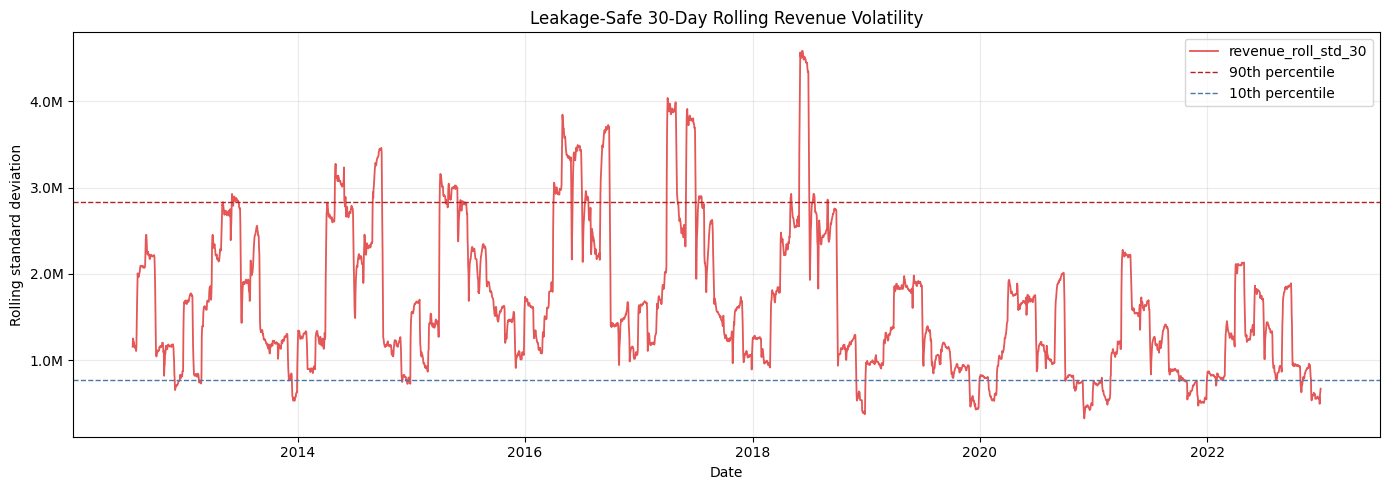

In [7]:
if not analysis_ready or rolling_df.empty:
    print("WARNING: Skipping rolling volatility analysis because rolling features are not available.")
else:
    valid_std_30 = rolling_df["revenue_roll_std_30"].dropna()
    if valid_std_30.empty:
        print("Not enough valid rolling standard deviation values.")
    else:
        high_vol_threshold = valid_std_30.quantile(0.90)
        low_vol_threshold = valid_std_30.quantile(0.10)
        rolling_df["high_volatility_30"] = rolling_df["revenue_roll_std_30"] >= high_vol_threshold
        rolling_df["low_volatility_30"] = rolling_df["revenue_roll_std_30"] <= low_vol_threshold

        high_periods = extract_flag_periods(rolling_df, "high_volatility_30", "revenue_roll_std_30", "high_volatility", top_n=15)
        low_periods = extract_flag_periods(rolling_df, "low_volatility_30", "revenue_roll_std_30", "low_volatility", top_n=15)
        volatility_periods_df = pd.concat([high_periods, low_periods], ignore_index=True)

        top_high_vol_days = (
            rolling_df.dropna(subset=["revenue_roll_std_30"])
            .sort_values("revenue_roll_std_30", ascending=False)
            [["date", "revenue", "revenue_roll_mean_30", "revenue_roll_std_30", "revenue_roll_std_7"]]
            .head(20)
        )

        high_volatility_period_text = (
            f"{high_periods.iloc[0]['start_date']} to {high_periods.iloc[0]['end_date']}"
            if not high_periods.empty
            else "None identified"
        )
        low_volatility_period_text = (
            f"{low_periods.iloc[0]['start_date']} to {low_periods.iloc[0]['end_date']}"
            if not low_periods.empty
            else "None identified"
        )

        threshold_df = pd.DataFrame([{
            "rolling_std_30_high_volatility_threshold_p90": high_vol_threshold,
            "rolling_std_30_low_volatility_threshold_p10": low_vol_threshold,
            "valid_rolling_std_30_days": len(valid_std_30),
        }])
        display(threshold_df)
        print("Top high-volatility days by shifted 30-day rolling standard deviation")
        display(top_high_vol_days)
        print("High- and low-volatility periods")
        display(volatility_periods_df)

        fig, ax = plt.subplots(figsize=(14, 5))
        ax.plot(rolling_df["date"], rolling_df["revenue_roll_std_30"], label="revenue_roll_std_30", color="#E45756", linewidth=1.3)
        ax.axhline(high_vol_threshold, color="#B22222", linestyle="--", linewidth=1, label="90th percentile")
        ax.axhline(low_vol_threshold, color="#4C78A8", linestyle="--", linewidth=1, label="10th percentile")
        ax.set_title("Leakage-Safe 30-Day Rolling Revenue Volatility")
        ax.set_xlabel("Date")
        ax.set_ylabel("Rolling standard deviation")
        ax.yaxis.set_major_formatter(currency_axis)
        ax.grid(alpha=0.25)
        ax.legend()
        plt.tight_layout()
        plt.show()

## 8. Rolling coefficient of variation

The rolling coefficient of variation divides 30-day rolling standard deviation by the absolute 30-day rolling mean. It highlights periods where revenue is unstable relative to its recent average level. Near-zero rolling means are treated as missing to avoid unstable ratios.

,rolling_cv_30_high_threshold_p90,rolling_cv_30_low_threshold_p10,valid_cv_days
0,0.485808,0.286114,3818


Highest rolling coefficient-of-variation days


,date,revenue,revenue_roll_mean_30,revenue_roll_std_30,revenue_roll_cv_30
815,2014-09-27,5922266.10,4.864322e+06,3.414851e+06,0.702020
814,2014-09-26,4802241.84,4.966928e+06,3.458883e+06,0.696383
813,2014-09-25,3991936.34,5.011056e+06,3.454457e+06,0.689367
809,2014-09-21,4973677.98,5.009702e+06,3.450058e+06,0.688675
810,2014-09-22,4691002.44,5.042814e+06,3.444601e+06,0.683071
812,2014-09-24,3651189.03,5.055418e+06,3.444924e+06,0.681432
808,2014-09-20,3934660.56,5.059226e+06,3.444754e+06,0.680885
811,2014-09-23,3267077.04,5.079016e+06,3.434660e+06,0.676245
807,2014-09-19,3152106.06,5.162586e+06,3.432053e+06,0.664793
806,2014-09-18,3245614.46,5.237461e+06,3.413241e+06,0.651698


Rolling CV high/low periods


,period_type,start_date,end_date,days,max_value,min_value,mean_value
0,high_cv,2017-03-31,2017-04-29,30,0.589824,0.504872,0.525294
1,high_cv,2014-09-02,2014-09-30,29,0.702020,0.486812,0.619423
2,high_cv,2019-12-31,2020-01-27,28,0.529268,0.496786,0.510418
3,high_cv,2016-09-04,2016-09-29,26,0.646740,0.501279,0.576884
4,high_cv,2022-09-04,2022-09-29,26,0.578503,0.496932,0.544611
5,high_cv,2020-09-05,2020-09-29,25,0.641014,0.496836,0.570378
6,high_cv,2015-08-17,2015-09-07,22,0.574475,0.491489,0.526099
7,high_cv,2021-03-31,2021-04-21,22,0.551675,0.489988,0.507919
8,high_cv,2015-01-09,2015-01-27,19,0.546371,0.489250,0.522394
9,high_cv,2018-09-12,2018-09-28,17,0.588486,0.489140,0.544680


Rolling CV flags unstable periods above 0.486 and unusually stable periods below 0.286.


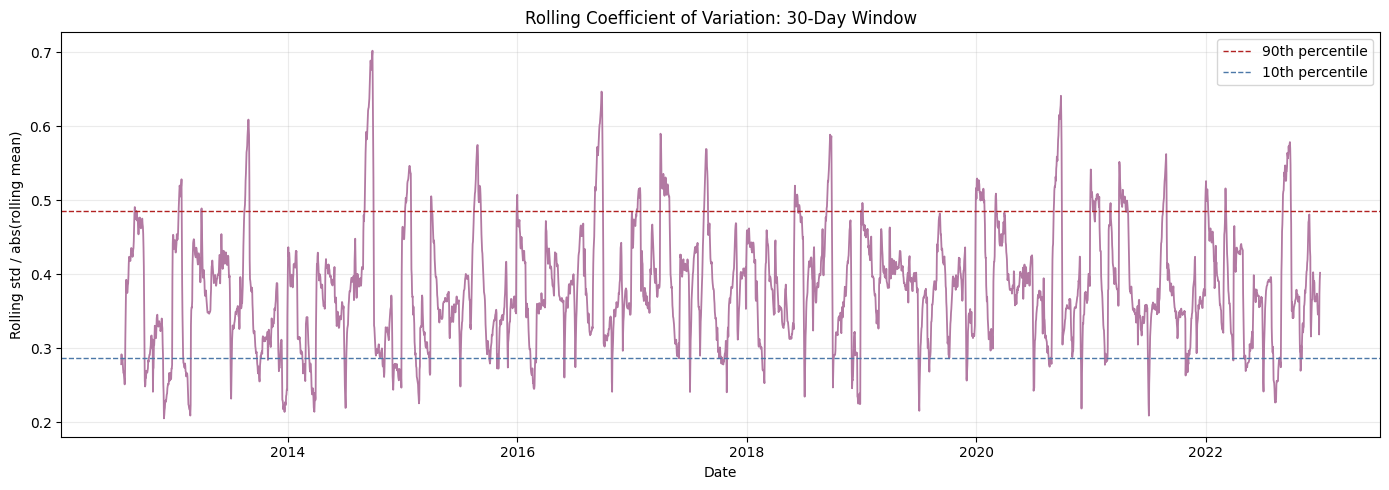

In [8]:
if not analysis_ready or rolling_df.empty:
    print("WARNING: Skipping rolling coefficient of variation because rolling features are not available.")
else:
    valid_cv = rolling_df["revenue_roll_cv_30"].replace([np.inf, -np.inf], np.nan).dropna()
    if valid_cv.empty:
        cv_statement = "Not enough valid rolling coefficient-of-variation values."
        print(cv_statement)
    else:
        high_cv_threshold = valid_cv.quantile(0.90)
        low_cv_threshold = valid_cv.quantile(0.10)
        rolling_df["high_cv_30"] = rolling_df["revenue_roll_cv_30"] >= high_cv_threshold
        rolling_df["low_cv_30"] = rolling_df["revenue_roll_cv_30"] <= low_cv_threshold

        high_cv_periods = extract_flag_periods(rolling_df, "high_cv_30", "revenue_roll_cv_30", "high_cv", top_n=10)
        low_cv_periods = extract_flag_periods(rolling_df, "low_cv_30", "revenue_roll_cv_30", "low_cv", top_n=10)
        cv_periods_df = pd.concat([high_cv_periods, low_cv_periods], ignore_index=True)

        cv_statement = (
            f"Rolling CV flags unstable periods above {high_cv_threshold:.3f} and unusually stable periods below {low_cv_threshold:.3f}."
        )

        top_cv_days = (
            rolling_df.dropna(subset=["revenue_roll_cv_30"])
            .sort_values("revenue_roll_cv_30", ascending=False)
            [["date", "revenue", "revenue_roll_mean_30", "revenue_roll_std_30", "revenue_roll_cv_30"]]
            .head(20)
        )

        display(pd.DataFrame([{
            "rolling_cv_30_high_threshold_p90": high_cv_threshold,
            "rolling_cv_30_low_threshold_p10": low_cv_threshold,
            "valid_cv_days": len(valid_cv),
        }]))
        print("Highest rolling coefficient-of-variation days")
        display(top_cv_days)
        print("Rolling CV high/low periods")
        display(cv_periods_df)
        print(cv_statement)

        fig, ax = plt.subplots(figsize=(14, 5))
        ax.plot(rolling_df["date"], rolling_df["revenue_roll_cv_30"], color="#B279A2", linewidth=1.3)
        ax.axhline(high_cv_threshold, color="#B22222", linestyle="--", linewidth=1, label="90th percentile")
        ax.axhline(low_cv_threshold, color="#4C78A8", linestyle="--", linewidth=1, label="10th percentile")
        ax.set_title("Rolling Coefficient of Variation: 30-Day Window")
        ax.set_xlabel("Date")
        ax.set_ylabel("Rolling std / abs(rolling mean)")
        ax.grid(alpha=0.25)
        ax.legend()
        plt.tight_layout()
        plt.show()

## 9. Rolling min/max and breakout checks

Compare current revenue with the previous 30-day historical range. The previous range is leakage-safe because it uses shifted rolling min and max. Breakout flags use a 10 percent margin beyond the prior range.

,days_with_new_high_vs_previous_30_day_max,days_with_new_low_vs_previous_30_day_min,large_high_breakouts_10pct_or_more,large_low_drops_10pct_or_more,valid_days_checked
0,129,127,73,74,3818


Largest breakout/drop days


,date,breakout_type,revenue,revenue_roll_max_30,revenue_roll_min_30,pct_above_prev_30_max,pct_below_prev_30_min
0,2015-03-30,large_high_breakout,14251354.04,6983791.47,1204115.66,104.063281,1083.553583
1,2017-03-30,large_high_breakout,17516038.82,8839810.76,1084768.59,98.149477,1514.725849
2,2021-03-30,large_high_breakout,10795905.35,5516765.31,679248.37,95.692670,1489.389953
3,2018-12-28,large_high_breakout,4637468.16,2379859.20,942014.91,94.863131,392.292437
4,2014-12-28,large_high_breakout,8484445.21,4372128.59,1490172.71,94.057541,469.359857
5,2022-03-30,large_high_breakout,11643208.73,6007208.86,1113577.08,93.820608,945.568281
6,2020-12-28,large_high_breakout,3627797.75,2102733.52,370653.23,72.527699,878.757895
7,2012-12-28,large_high_breakout,8573663.31,4994041.71,1765509.34,71.677847,385.619822
8,2013-12-29,large_high_breakout,6516622.75,3807864.44,1444180.43,71.135891,351.233282
9,2016-03-30,large_high_breakout,14545392.64,8569336.81,709982.79,69.737670,1948.696510


Rolling min/max checks found 73 large high breakouts and 74 large low drops versus the previous 30-day range.


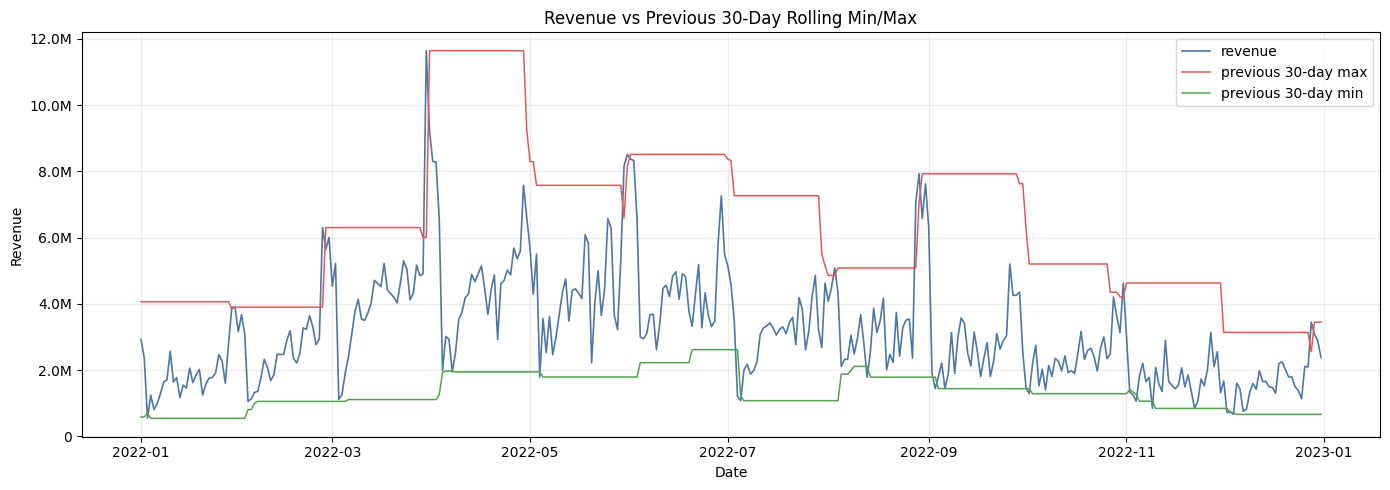

In [9]:
if not analysis_ready or rolling_df.empty:
    print("WARNING: Skipping rolling min/max checks because rolling features are not available.")
else:
    valid_range = rolling_df.dropna(subset=["revenue", "revenue_roll_max_30", "revenue_roll_min_30"]).copy()
    if valid_range.empty:
        breakout_statement = "Not enough history to compare revenue with the previous 30-day range."
        print(breakout_statement)
    else:
        valid_range["pct_above_prev_30_max"] = np.where(
            valid_range["revenue_roll_max_30"].abs() < 1e-9,
            np.nan,
            (valid_range["revenue"] - valid_range["revenue_roll_max_30"]) / valid_range["revenue_roll_max_30"].abs() * 100,
        )
        valid_range["pct_below_prev_30_min"] = np.where(
            valid_range["revenue_roll_min_30"].abs() < 1e-9,
            np.nan,
            (valid_range["revenue"] - valid_range["revenue_roll_min_30"]) / valid_range["revenue_roll_min_30"].abs() * 100,
        )
        valid_range["new_high_vs_prev_30"] = valid_range["revenue"] > valid_range["revenue_roll_max_30"]
        valid_range["new_low_vs_prev_30"] = valid_range["revenue"] < valid_range["revenue_roll_min_30"]
        valid_range["large_high_breakout"] = valid_range["pct_above_prev_30_max"] >= 10
        valid_range["large_low_drop"] = valid_range["pct_below_prev_30_min"] <= -10

        high_breakouts = valid_range.loc[valid_range["large_high_breakout"]].sort_values("pct_above_prev_30_max", ascending=False)
        low_drops = valid_range.loc[valid_range["large_low_drop"]].sort_values("pct_below_prev_30_min", ascending=True)
        breakout_days_df = pd.concat([
            high_breakouts.assign(breakout_type="large_high_breakout").head(15),
            low_drops.assign(breakout_type="large_low_drop").head(15),
        ], ignore_index=True)

        breakout_summary_df = pd.DataFrame([{
            "days_with_new_high_vs_previous_30_day_max": int(valid_range["new_high_vs_prev_30"].sum()),
            "days_with_new_low_vs_previous_30_day_min": int(valid_range["new_low_vs_prev_30"].sum()),
            "large_high_breakouts_10pct_or_more": int(valid_range["large_high_breakout"].sum()),
            "large_low_drops_10pct_or_more": int(valid_range["large_low_drop"].sum()),
            "valid_days_checked": len(valid_range),
        }])

        breakout_statement = (
            f"Rolling min/max checks found {int(valid_range['large_high_breakout'].sum())} large high breakouts and {int(valid_range['large_low_drop'].sum())} large low drops versus the previous 30-day range."
        )

        display(breakout_summary_df)
        print("Largest breakout/drop days")
        display(breakout_days_df[[
            "date", "breakout_type", "revenue", "revenue_roll_max_30", "revenue_roll_min_30",
            "pct_above_prev_30_max", "pct_below_prev_30_min",
        ]])
        print(breakout_statement)

        chart_df = rolling_df.dropna(subset=["revenue"]).tail(365).copy()
        fig, ax = plt.subplots(figsize=(14, 5))
        ax.plot(chart_df["date"], chart_df["revenue"], label="revenue", color="#4C78A8", linewidth=1.2)
        ax.plot(chart_df["date"], chart_df["revenue_roll_max_30"], label="previous 30-day max", color="#E45756", linewidth=1.1)
        ax.plot(chart_df["date"], chart_df["revenue_roll_min_30"], label="previous 30-day min", color="#54A24B", linewidth=1.1)
        ax.set_title("Revenue vs Previous 30-Day Rolling Min/Max")
        ax.set_xlabel("Date")
        ax.set_ylabel("Revenue")
        ax.yaxis.set_major_formatter(currency_axis)
        ax.grid(alpha=0.25)
        ax.legend()
        plt.tight_layout()
        plt.show()

## 10. Short-term trend signals

Use rolling mean differences to identify short-term upward or downward movement. These are exploratory feature-engineering signals, not causal explanations.

,valid_trend_days,share_short_term_above_30_day_mean,share_30_day_above_90_day_mean,roll_mean_7_vs_30_p25,roll_mean_7_vs_30_p75,correlation_roll_mean_7_vs_30_with_current_revenue,correlation_roll_mean_30_vs_90_with_current_revenue
0,3788,0.424498,0.43189,-696158.314274,552955.288905,0.211925,0.39873


Strong short-term trend periods


,period_type,start_date,end_date,days,max_value,min_value,mean_value
0,strong_short_term_up,2016-03-13,2016-04-08,27,4.153139e+06,6.038808e+05,1.656586e+06
1,strong_short_term_up,2017-03-16,2017-04-08,24,5.850489e+06,8.128495e+05,2.356927e+06
2,strong_short_term_up,2020-03-15,2020-04-07,24,2.589111e+06,5.786609e+05,1.443877e+06
3,strong_short_term_up,2021-03-17,2021-04-07,22,3.054534e+06,6.109635e+05,1.322220e+06
4,strong_short_term_up,2015-03-20,2015-04-08,20,4.471303e+06,5.533665e+05,1.890208e+06
5,strong_short_term_up,2013-03-19,2013-04-07,20,3.508436e+06,6.368697e+05,1.789929e+06
6,strong_short_term_up,2019-03-19,2019-04-06,19,2.419748e+06,5.985210e+05,1.286318e+06
7,strong_short_term_up,2018-04-21,2018-05-07,17,3.677651e+06,8.695749e+05,1.793344e+06
8,strong_short_term_up,2016-04-21,2016-05-06,16,5.066398e+06,6.745706e+05,2.354561e+06
9,strong_short_term_up,2013-04-24,2013-05-07,14,3.524170e+06,6.759739e+05,1.937359e+06


Short-term trend signals appear useful as exploratory features; roll_mean_7_vs_30 has correlation 0.212 with current revenue.
Note: observed_revenue_vs_roll_mean_30 is a diagnostic after current revenue is known, not a same-day forecast feature.


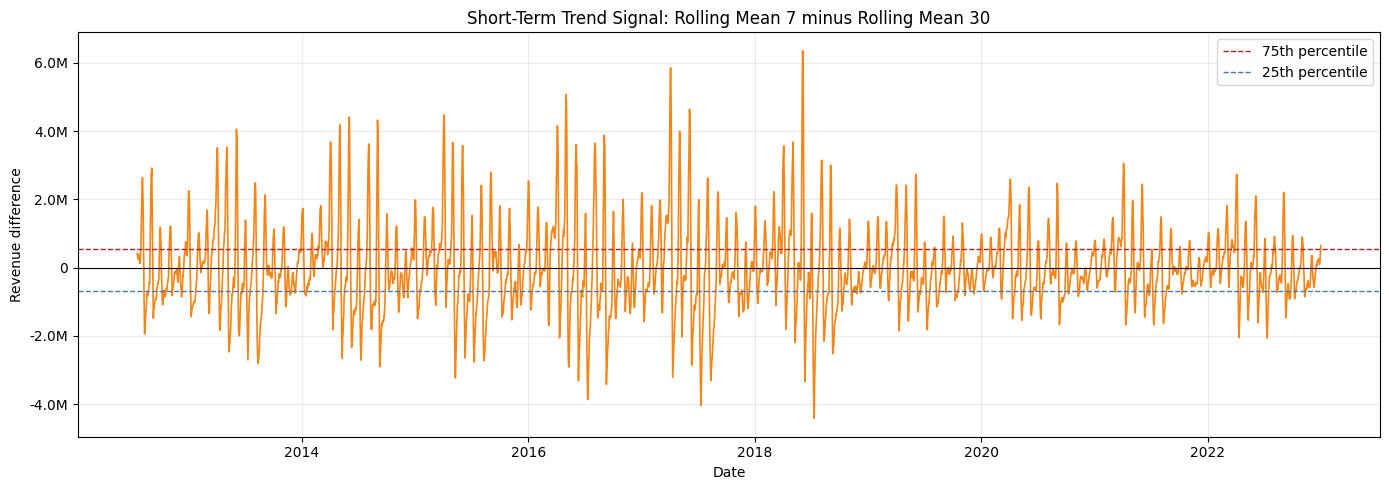

In [10]:
if not analysis_ready or rolling_df.empty:
    print("WARNING: Skipping short-term trend signals because rolling features are not available.")
else:
    trend_df = rolling_df.dropna(subset=["roll_mean_7_vs_30", "roll_mean_30_vs_90"]).copy()
    if trend_df.empty:
        short_term_trend_statement = "Not enough rolling mean history to evaluate short-term trend signals."
        print(short_term_trend_statement)
    else:
        trend_df["short_term_direction"] = np.select(
            [trend_df["roll_mean_7_vs_30"] > 0, trend_df["roll_mean_7_vs_30"] < 0],
            ["short_term_above_medium_term", "short_term_below_medium_term"],
            default="flat",
        )
        trend_df["medium_term_direction"] = np.select(
            [trend_df["roll_mean_30_vs_90"] > 0, trend_df["roll_mean_30_vs_90"] < 0],
            ["medium_term_above_long_term", "medium_term_below_long_term"],
            default="flat",
        )
        trend_df["observed_revenue_vs_roll_mean_30"] = trend_df["revenue"] - trend_df["revenue_roll_mean_30"]
        trend_df["observed_revenue_pct_vs_roll_mean_30"] = np.where(
            trend_df["revenue_roll_mean_30"].abs() < 1e-9,
            np.nan,
            trend_df["observed_revenue_vs_roll_mean_30"] / trend_df["revenue_roll_mean_30"].abs() * 100,
        )

        up_threshold = trend_df["roll_mean_7_vs_30"].quantile(0.75)
        down_threshold = trend_df["roll_mean_7_vs_30"].quantile(0.25)
        rolling_df["strong_short_term_up_signal"] = rolling_df["roll_mean_7_vs_30"] >= up_threshold
        rolling_df["strong_short_term_down_signal"] = rolling_df["roll_mean_7_vs_30"] <= down_threshold
        up_periods = extract_flag_periods(rolling_df, "strong_short_term_up_signal", "roll_mean_7_vs_30", "strong_short_term_up", top_n=10)
        down_periods = extract_flag_periods(rolling_df, "strong_short_term_down_signal", "roll_mean_7_vs_30", "strong_short_term_down", top_n=10)
        trend_periods_df = pd.concat([up_periods, down_periods], ignore_index=True)

        trend_summary_df = pd.DataFrame([{
            "valid_trend_days": len(trend_df),
            "share_short_term_above_30_day_mean": float((trend_df["roll_mean_7_vs_30"] > 0).mean()),
            "share_30_day_above_90_day_mean": float((trend_df["roll_mean_30_vs_90"] > 0).mean()),
            "roll_mean_7_vs_30_p25": down_threshold,
            "roll_mean_7_vs_30_p75": up_threshold,
            "correlation_roll_mean_7_vs_30_with_current_revenue": trend_df["roll_mean_7_vs_30"].corr(trend_df["revenue"]),
            "correlation_roll_mean_30_vs_90_with_current_revenue": trend_df["roll_mean_30_vs_90"].corr(trend_df["revenue"]),
        }])

        corr_7_30 = trend_summary_df.loc[0, "correlation_roll_mean_7_vs_30_with_current_revenue"]
        if pd.notna(corr_7_30) and abs(corr_7_30) >= 0.20:
            short_term_trend_statement = f"Short-term trend signals appear useful as exploratory features; roll_mean_7_vs_30 has correlation {corr_7_30:.3f} with current revenue."
        else:
            short_term_trend_statement = f"Short-term trend signals look weaker by simple correlation; roll_mean_7_vs_30 correlation is {corr_7_30:.3f}."

        display(trend_summary_df)
        print("Strong short-term trend periods")
        display(trend_periods_df)
        print(short_term_trend_statement)
        print("Note: observed_revenue_vs_roll_mean_30 is a diagnostic after current revenue is known, not a same-day forecast feature.")

        fig, ax = plt.subplots(figsize=(14, 5))
        ax.plot(rolling_df["date"], rolling_df["roll_mean_7_vs_30"], color="#F58518", linewidth=1.2)
        ax.axhline(0, color="black", linewidth=0.8)
        ax.axhline(up_threshold, color="#B22222", linestyle="--", linewidth=1, label="75th percentile")
        ax.axhline(down_threshold, color="#4C78A8", linestyle="--", linewidth=1, label="25th percentile")
        ax.set_title("Short-Term Trend Signal: Rolling Mean 7 minus Rolling Mean 30")
        ax.set_xlabel("Date")
        ax.set_ylabel("Revenue difference")
        ax.yaxis.set_major_formatter(currency_axis)
        ax.grid(alpha=0.25)
        ax.legend()
        plt.tight_layout()
        plt.show()

## 11. Forecast feature preview

Preview leakage-safe rolling forecast features. The table is not saved to file.

In [11]:
if not analysis_ready or rolling_df.empty:
    print("WARNING: Skipping forecast feature preview because rolling features are not available.")
else:
    preview_cols = ["date", "revenue"] + ROLL_FEATURE_COLUMNS
    available_preview_cols = [col for col in preview_cols if col in rolling_df.columns]
    feature_preview = rolling_df[available_preview_cols].copy()

    non_null_preview = feature_preview.dropna(subset=[col for col in ROLL_FEATURE_COLUMNS if col in feature_preview.columns], how="all")
    if non_null_preview.empty:
        display(feature_preview.head(20))
    else:
        display(non_null_preview.head(20))

    recommended_rolling_features = [
        "revenue_roll_mean_7",
        "revenue_roll_mean_14",
        "revenue_roll_mean_30",
        "revenue_roll_mean_90",
        "revenue_roll_std_7",
        "revenue_roll_std_30",
        "revenue_roll_cv_30",
        "revenue_roll_max_30",
        "revenue_roll_min_30",
        "roll_mean_7_vs_30",
        "roll_mean_30_vs_90",
    ]
    print("Confirmed: every displayed rolling feature was computed after applying revenue.shift(1).")
    print("Recommended baseline rolling features:", ", ".join(recommended_rolling_features))

,date,revenue,revenue_roll_mean_7,revenue_roll_mean_14,revenue_roll_mean_30,revenue_roll_mean_90,revenue_roll_std_7,revenue_roll_std_30,revenue_roll_max_30,revenue_roll_min_30,roll_mean_7_vs_30,roll_mean_30_vs_90
3,2012-07-07,2667930.94,3.643117e+06,NaN,NaN,NaN,1.290967e+06,NaN,NaN,NaN,NaN,NaN
4,2012-07-08,2360851.90,3.399320e+06,NaN,NaN,NaN,1.161383e+06,NaN,NaN,NaN,NaN,NaN
5,2012-07-09,3548386.46,3.191627e+06,NaN,NaN,NaN,1.107832e+06,NaN,NaN,NaN,NaN,NaN
6,2012-07-10,5234938.62,3.251087e+06,NaN,NaN,NaN,1.001522e+06,NaN,NaN,NaN,NaN,NaN
7,2012-07-11,5582884.78,3.534494e+06,3.534494e+06,NaN,NaN,1.182417e+06,NaN,NaN,NaN,NaN,NaN
8,2012-07-12,5734632.02,3.600114e+06,3.790543e+06,NaN,NaN,1.292887e+06,NaN,NaN,NaN,NaN,NaN
9,2012-07-13,5309511.71,4.026236e+06,4.006553e+06,NaN,NaN,1.448836e+06,NaN,NaN,NaN,NaN,NaN
10,2012-07-14,3820831.41,4.348448e+06,4.136849e+06,NaN,NaN,1.447390e+06,NaN,NaN,NaN,NaN,NaN
11,2012-07-15,3948841.28,4.513148e+06,4.108120e+06,NaN,NaN,1.280233e+06,NaN,NaN,NaN,NaN,NaN
12,2012-07-16,3503801.49,4.740004e+06,4.094847e+06,NaN,NaN,9.273440e+05,NaN,NaN,NaN,NaN,NaN


Confirmed: every displayed rolling feature was computed after applying revenue.shift(1).
Recommended baseline rolling features: revenue_roll_mean_7, revenue_roll_mean_14, revenue_roll_mean_30, revenue_roll_mean_90, revenue_roll_std_7, revenue_roll_std_30, revenue_roll_cv_30, revenue_roll_max_30, revenue_roll_min_30, roll_mean_7_vs_30, roll_mean_30_vs_90


## 12. Key observations and warnings

Summarize rolling trend, volatility, coefficient-of-variation, breakout, and feature-engineering signals. These are exploratory and should be validated with leakage-safe model backtests.

In [12]:
if analysis_ready and not rolling_df.empty:
    if not volatility_periods_df.empty:
        high_periods_summary = volatility_periods_df.loc[volatility_periods_df["period_type"] == "high_volatility"].head(3)
        low_periods_summary = volatility_periods_df.loc[volatility_periods_df["period_type"] == "low_volatility"].head(3)
        high_volatility_period_text = "; ".join(
            f"{row.start_date} to {row.end_date} ({int(row.days)} days)"
            for row in high_periods_summary.itertuples()
        ) or "None identified"
        low_volatility_period_text = "; ".join(
            f"{row.start_date} to {row.end_date} ({int(row.days)} days)"
            for row in low_periods_summary.itertuples()
        ) or "None identified"

    if not rolling_window_metrics_df.empty and most_informative_window is not None:
        best_metric_row = rolling_window_metrics_df.loc[rolling_window_metrics_df["window_days"] == most_informative_window].iloc[0]
        window_detail = (
            f"{most_informative_window}-day window; MAE {best_metric_row['mae_vs_current_revenue']:,.2f}, "
            f"correlation {best_metric_row['correlation_with_current_revenue']:.3f}"
        )
    else:
        window_detail = "not available"

    if not breakout_days_df.empty:
        breakout_detail = breakout_statement
    else:
        breakout_detail = "No large rolling min/max breakouts or drops were displayed."

    cv_detail = cv_statement
    recommended_text = ", ".join(recommended_rolling_features) if recommended_rolling_features else "None"

    print("Insight summary")
    print(f"- Short-term trend signals: {short_term_trend_statement}")
    print(f"- Most informative rolling mean window: {window_detail}")
    print(f"- High rolling-volatility periods: {high_volatility_period_text}")
    print(f"- Low rolling-volatility periods: {low_volatility_period_text}")
    print(f"- Rolling coefficient of variation: {cv_detail}")
    print(f"- Rolling min/max breakouts or drops: {breakout_detail}")
    print(f"- Recommended rolling features for forecasting: {recommended_text}")
    print("- Leakage confirmation: rolling means, standard deviations, min/max, CV, and rolling-mean difference features were created from revenue.shift(1).")
else:
    print("Insight summary")
    print("- Rolling-statistics analysis could not be completed because usable daily revenue data or rolling features were not available.")

print("\nWarnings and data notes")
if warning_messages:
    for message in dict.fromkeys(warning_messages):
        print(f"- {message}")
else:
    print("- No critical warnings.")

Insight summary
- Short-term trend signals: Short-term trend signals appear useful as exploratory features; roll_mean_7_vs_30 has correlation 0.212 with current revenue.
- Most informative rolling mean window: 7-day window; MAE 1,248,832.79, correlation 0.695
- High rolling-volatility periods: 2016-04-02 to 2016-05-28 (57 days); 2017-03-31 to 2017-05-05 (36 days); 2018-05-31 to 2018-07-01 (32 days)
- Low rolling-volatility periods: 2020-10-29 to 2021-01-26 (90 days); 2021-10-16 to 2021-12-30 (76 days); 2019-11-29 to 2019-12-31 (33 days)
- Rolling coefficient of variation: Rolling CV flags unstable periods above 0.486 and unusually stable periods below 0.286.
- Rolling min/max breakouts or drops: Rolling min/max checks found 73 large high breakouts and 74 large low drops versus the previous 30-day range.
- Recommended rolling features for forecasting: revenue_roll_mean_7, revenue_roll_mean_14, revenue_roll_mean_30, revenue_roll_mean_90, revenue_roll_std_7, revenue_roll_std_30, revenue_r